In [2]:
# Install dependencies if needed (optional inside notebook)
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# =============================
# 1. LIBRARIES
# =============================

import sys
import os
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

import warnings
warnings.filterwarnings("ignore")

from config import *

In [4]:
# =============================
# 2. LOAD DATA
# =============================

train_df = pd.read_csv(TRAIN_DATA_PATH)
test_df = pd.read_csv(TEST_DATA_PATH)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (800, 21)
Test shape: (200, 20)


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,target
0,432.475954,289.373016,481.315600,358.755566,802.659004,176.761177,72.648102,720.969179,36.327684,83.768878,...,4.385848,516.789458,19.624422,13.162440,42.351948,35.920392,20.755984,13.814300,384.497136,14.364922
1,517.596250,330.448341,585.920055,22.684031,169.813240,335.601640,284.451476,748.101047,73.701438,358.147215,...,5.563334,2.960064,20.721878,17.740184,1.726915,167.576065,75.492679,2.480979,303.710869,19.984801
2,189.439350,553.888820,165.833790,202.465927,176.695586,321.155049,407.278389,161.245668,282.269025,221.570899,...,4.536947,581.823741,101.695639,0.653592,486.859084,117.491548,6.420465,20.713314,22.651537,12.944351
3,237.307878,195.894881,416.752252,468.729031,611.693517,301.411711,241.880655,49.597044,122.396821,13.828319,...,5.518968,45.014729,196.350455,47.638515,411.414213,67.142022,115.630943,8.927957,388.240433,14.792440
4,602.845256,16.103208,221.759979,345.765574,558.588369,276.704241,408.069566,19.390813,138.769765,146.662193,...,2.136214,133.590430,197.634584,26.278027,111.127557,172.181136,85.869642,30.537857,625.931837,11.802634


All the features are float type and are complete.

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   feature_0   800 non-null    float64
 1   feature_1   800 non-null    float64
 2   feature_2   800 non-null    float64
 3   feature_3   800 non-null    float64
 4   feature_4   800 non-null    float64
 5   feature_5   800 non-null    float64
 6   feature_6   800 non-null    float64
 7   feature_7   800 non-null    float64
 8   feature_8   800 non-null    float64
 9   feature_9   800 non-null    float64
 10  feature_10  800 non-null    float64
 11  feature_11  800 non-null    float64
 12  feature_12  800 non-null    float64
 13  feature_13  800 non-null    float64
 14  feature_14  800 non-null    float64
 15  feature_15  800 non-null    float64
 16  feature_16  800 non-null    float64
 17  feature_17  800 non-null    float64
 18  feature_18  800 non-null    float64
 19  feature_19  800 non-null    f

There are not null values and all the columns are complete.

In [6]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
feature_0,800.0,468.181612,270.797415,0.916648,239.330140,477.750620,704.650292,940.771543
feature_1,800.0,301.960218,170.691136,0.800119,157.338244,303.257176,448.878174,595.359858
feature_2,800.0,317.132996,176.501920,0.173025,167.516318,326.310194,474.484472,614.271632
feature_3,800.0,283.213456,157.698215,0.308823,151.302826,294.574403,415.806162,549.896216
feature_4,800.0,485.975950,272.594030,0.598527,250.305362,493.470486,720.747672,950.017444
feature_5,800.0,320.953859,185.157189,0.997347,158.374610,328.722464,480.076559,638.199832
feature_6,800.0,217.136330,123.660691,0.402436,106.876625,217.098090,327.411334,426.308251
feature_7,800.0,387.196289,235.131376,0.474825,195.037853,364.124238,588.565017,809.346792
feature_8,800.0,179.485453,104.059309,0.727850,94.220273,173.364771,268.790459,367.084755
feature_9,800.0,196.003058,111.042671,0.264253,95.052359,199.587048,291.546642,384.919108


The std are very different, if we think in use a lineal model, we need to scalate the data.

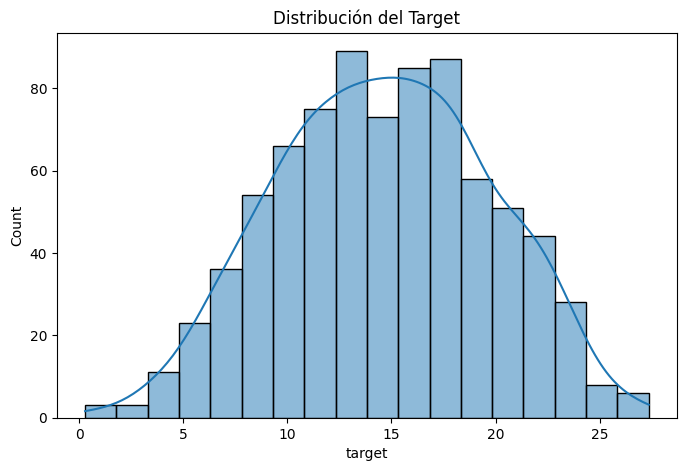

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(train_df["target"], kde=True)
plt.title("Distribución del Target")
plt.show()

The target is normal distributed, there is no bias or log-transform. We could use the data like these.

In [8]:
# =============================
# SEPARATE x e y
# =============================

x = train_df.drop("target", axis=1)
y = train_df["target"]

print("Shape x:", x.shape)
print("Shape y:", y.shape)

Shape x: (800, 20)
Shape y: (800,)


In [9]:
# =============================
# BASELINE MODEL
# =============================

baseline_model = LinearRegression()

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rmse_scores = -cross_val_score(
    baseline_model,
    x,
    y,
    scoring="neg_root_mean_squared_error",
    cv=kf
)

r2_scores = cross_val_score(
    baseline_model,
    x,
    y,
    scoring="r2",
    cv=kf
)

print("Baseline Linear Regression")
print("RMSE mean:", rmse_scores.mean())
print("RMSE std:", rmse_scores.std())
print("R2 mean:", r2_scores.mean())

Baseline Linear Regression
RMSE mean: 2.8436329587238087
RMSE std: 0.14093229325184722
R2 mean: 0.6837755137167891


The ~68% of the mean are explained by a lineal model, it is good for a baseline.\
The low std indicates that the dataset is stable, there is a low risk of overfitting.

Let's try with:

Linear Models:
- LinearRegression
- Ridge
- Lasso

No Linear Models:
- DecisionTree
- RandomForest
- GradientBoosting

In [10]:
# =============================
# MODELS BENCHMARK
# =============================

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "Lasso": Lasso(random_state=RANDOM_STATE),
    "DecisionTree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "RandomForest": RandomForestRegressor(random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE)
}

results = []

for name, model in models.items():
    
    rmse = -cross_val_score(
        model,
        x,
        y,
        scoring="neg_root_mean_squared_error",
        cv=kf
    )
    
    r2 = cross_val_score(
        model,
        x,
        y,
        scoring="r2",
        cv=kf
    )
    
    results.append({
        "Model": name,
        "RMSE_mean": rmse.mean(),
        "RMSE_std": rmse.std(),
        "R2_mean": r2.mean()
    })

results_df = pd.DataFrame(results).sort_values("RMSE_mean")

results_df

,Model,RMSE_mean,RMSE_std,R2_mean
5,GradientBoosting,2.135048,0.097574,0.821044
4,RandomForest,2.529666,0.105940,0.750087
1,Ridge,2.843627,0.140936,0.683778
0,LinearRegression,2.843633,0.140932,0.683776
2,Lasso,2.884110,0.149090,0.675515
3,DecisionTree,3.772208,0.244339,0.447180


The biggest R2 is 0.82, bigger than the linear baseline 0.68, the problem has no linear variables.

The Best model is GradientBoosting, so we will start with this one.

In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 3, 5],
    "subsample": [0.8, 1.0]
}

gbr = GradientBoostingRegressor(random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x, y)

print("Best RMSE:", -grid_search.best_score_)
print("Best Params:", grid_search.best_params_)

Fitting 5 folds for each of 486 candidates, totalling 2430 fits
Best RMSE: 1.959908768932138
Best Params: {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 300, 'subsample': 0.8}


We have a improve from 2,135 to 1,959

the best params are:
{
 'learning_rate': 0.1,
 'max_depth': 2,
 'min_samples_leaf': 5,
 'min_samples_split': 2,
 'n_estimators': 300,
 'subsample': 0.8
}


In [12]:
# =============================
# TRAIN FINAL MODEL
# =============================

best_model = grid_search.best_estimator_

best_model.fit(x, y)

# Predicciones en train (para análisis)
y_pred = best_model.predict(x)

# Métricas en train
rmse_train = np.sqrt(mean_squared_error(y, y_pred))
r2_train = r2_score(y, y_pred)

print("Train RMSE:", rmse_train)
print("Train R2:", r2_train)

Train RMSE: 1.0840170327970515
Train R2: 0.9545781683535279


We hace an ~5% of error, it is very good.

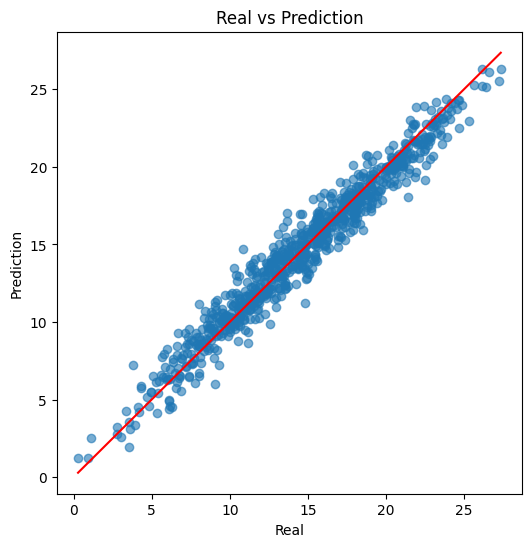

In [13]:
# =============================
# REAL vs PREDICTION
# =============================

plt.figure(figsize=(6,6))
plt.scatter(y, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red')
plt.xlabel("Real")
plt.ylabel("Prediction")
plt.title("Real vs Prediction")
plt.show()

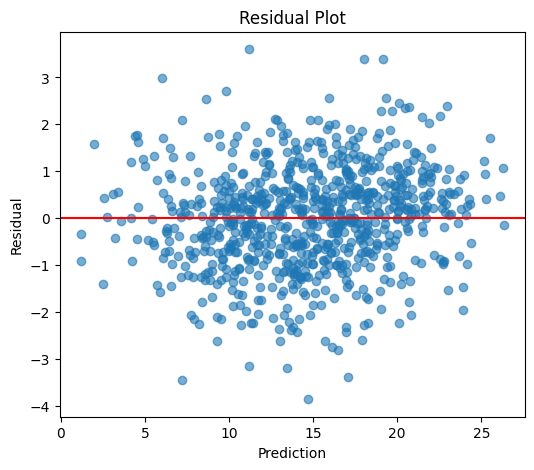

In [14]:
# =============================
# RESIDUALS
# =============================

residuals = y - y_pred

plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red')
plt.xlabel("Prediction")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

In [15]:
# =============================
# PREDICTION IN BLIND TEST
# =============================

blind_predictions = best_model.predict(test_df)

submission = pd.DataFrame({
    "prediction": blind_predictions
})

submission.head()

,prediction
0,11.507947
1,11.684680
2,15.225028
3,11.815175
4,16.990403


In [17]:
best_model.get_params()

{'alpha': 0.9,
 'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.1,
 'loss': 'squared_error',
 'max_depth': 2,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 5,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 300,
 'n_iter_no_change': None,
 'random_state': 42,
 'subsample': 0.8,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

In [18]:
print({
    "loss": best_model.loss,
    "learning_rate": best_model.learning_rate,
    "n_estimators": best_model.n_estimators,
    "subsample": best_model.subsample,
    "criterion": best_model.criterion,
    "min_samples_split": best_model.min_samples_split,
    "min_samples_leaf": best_model.min_samples_leaf,
    "min_weight_fraction_leaf": best_model.min_weight_fraction_leaf,
    "max_depth": best_model.max_depth,
    "min_impurity_decrease": best_model.min_impurity_decrease,
    "init": best_model.init,
    "random_state": best_model.random_state,
    "max_features": best_model.max_features,
    "alpha": best_model.alpha,
    "verbose": best_model.verbose,
    "max_leaf_nodes": best_model.max_leaf_nodes,
    "warm_start": best_model.warm_start,
    "validation_fraction": best_model.validation_fraction,
    "n_iter_no_change": best_model.n_iter_no_change,
    "tol": best_model.tol,
    "ccp_alpha": best_model.ccp_alpha
})

{'loss': 'squared_error', 'learning_rate': 0.1, 'n_estimators': 300, 'subsample': 0.8, 'criterion': 'friedman_mse', 'min_samples_split': 2, 'min_samples_leaf': 5, 'min_weight_fraction_leaf': 0.0, 'max_depth': 2, 'min_impurity_decrease': 0.0, 'init': None, 'random_state': 42, 'max_features': None, 'alpha': 0.9, 'verbose': 0, 'max_leaf_nodes': None, 'warm_start': False, 'validation_fraction': 0.1, 'n_iter_no_change': None, 'tol': 0.0001, 'ccp_alpha': 0.0}
